<a href="https://colab.research.google.com/github/Akuaja7/setiawan/blob/main/UAS__NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q transformers==4.46.3
!pip install -q datasets
!pip install -q evaluate
!pip install -q accelerate
!pip install -q sentencepiece
!pip install -q scikit-learn
!pip install -q spacy
!pip install -q matplotlib
!pip install -q pandas

!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 89.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import evaluate
# import spacy # No longer needed
from difflib import SequenceMatcher

from datasets import load_dataset

print("="*60)
print("VERSI LIBRARY")
print("="*60)

print("Torch         :", torch.__version__)
print("GPU Available :", torch.cuda.is_available())

import transformers
print("Transformers  :", transformers.__version__)

print("="*60)

VERSI LIBRARY
Torch         : 2.11.0+cu128
GPU Available : True
Transformers  : 4.46.3


In [3]:
dataset = load_dataset("suryaadhi/ppmb-qa-dataset")

df = dataset["train"].to_pandas()

print("="*60)
print("DATASET BERHASIL DIMUAT")
print("="*60)

print("Jumlah Data :", len(df))
print("Jumlah Kolom :", len(df.columns))

print("\nNama Kolom")
print(df.columns)

display(df.head())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


DATASET BERHASIL DIMUAT
Jumlah Data : 1059
Jumlah Kolom : 2

Nama Kolom
Index(['query', 'answer'], dtype='object')


,query,answer
0,Information for prospective agrotechnology stu...,Here is information regarding new student admi...
1,"How competitive is Communication Studies, sis/...","Alright, I will provide information regarding ..."
2,"So, will the golden ticket requirements not be...","Yes, the **Golden Ticket requirements will be ..."
3,"Hello sis/bro, how do I get the golden ticket?...",Hello! To get a Golden Ticket at UPN Veteran E...
4,"Min, may I ask about the mechanical engineerin...",Hello! You are asking about the difference in ...


In [4]:
print("="*60)
print("INFORMASI DATASET")
print("="*60)

df.info()

print("\nMissing Value")

print(df.isnull().sum())

INFORMASI DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1059 entries, 0 to 1058
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   query   1059 non-null   object
 1   answer  1059 non-null   object
dtypes: object(2)
memory usage: 16.7+ KB

Missing Value
query     0
answer    0
dtype: int64


In [5]:
#Statistik Panjang Pertanyaan
df["query_length"] = df["query"].astype(str).apply(len)

df["answer_length"] = df["answer"].astype(str).apply(len)

df[["query_length","answer_length"]].describe()

,query_length,answer_length
count,1059.000000,1059.000000
mean,72.952786,1759.857413
std,46.256677,1457.167554
min,18.000000,88.000000
25%,43.000000,840.000000
50%,61.000000,1381.000000
75%,90.000000,2236.000000
max,384.000000,9608.000000


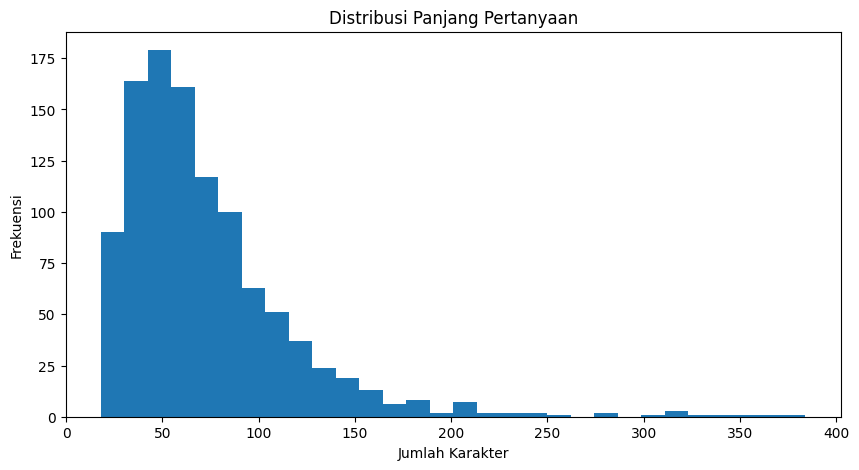

In [6]:
#Grafik Distribusi Panjang Pertanyaan
plt.figure(figsize=(10,5))

plt.hist(df["query_length"], bins=30)

plt.title("Distribusi Panjang Pertanyaan")

plt.xlabel("Jumlah Karakter")

plt.ylabel("Frekuensi")

plt.show()

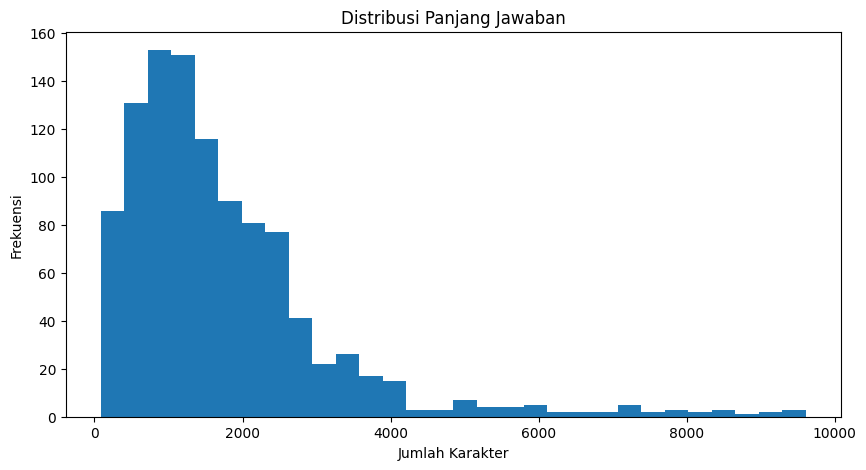

In [7]:
#Grafik Distribusi Panjang Jawaban
plt.figure(figsize=(10,5))

plt.hist(df["answer_length"], bins=30)

plt.title("Distribusi Panjang Jawaban")

plt.xlabel("Jumlah Karakter")

plt.ylabel("Frekuensi")

plt.show()

In [8]:
#Menampilkan Contoh Data Acak
df.sample(10)

,query,answer,query_length,answer_length
171,Is the CBT test offline/online?,"Based on the provided source, the CBT test for...",31,1342
99,"Min, what are the clothing regulations for UTBK?","Based on the available sources, the clothing r...",48,278
739,Iki maksude golden tiket gawe arek eligible sg...,"Ndhelok informasi teko sumber sing diwenehno, ...",85,760
775,min UPN penilaian snbp ne opo onok track recor...,Penilaian Seleksi Nasional Berdasarkan Prestas...,55,1628
264,"Min, can the independent selection pathway use...","Yes, the independent selection pathway at UPN ...",52,1487
189,"For gap year students, do they also submit gra...","Certainly, let's discuss your questions regard...",84,3329
222,Does online CBT mean we can take the test from...,"Yes, the **Independent pathway CBT (Computer B...",72,1355
688,Jalur mandiri kemitraan udah buka min?,"Ya, beberapa jalur mandiri kemitraan di UPN ""V...",38,1451
449,Berapa kuota Golden Ticket min?,"Berdasarkan sumber yang tersedia, tidak ada in...",31,317
210,Please spill the number of applicants for othe...,"Certainly, here is the 2024 applicant data for...",73,2886


"EDA dilakukan untuk memahami karakteristik dataset sebelum proses pelatihan model. Pada tahap ini saya memeriksa jumlah data, struktur kolom, missing value, serta distribusi panjang pertanyaan dan jawaban. Informasi ini membantu memastikan kualitas data sebelum dilakukan preprocessing dan pelatihan model IndoBERT."

Preprocessing Teks

In [9]:
import re

def clean_text(text):
    text = str(text).lower()

    # Hapus URL
    text = re.sub(r"http\S+", "", text)

    # Hapus karakter selain huruf, angka, dan spasi
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)

    # Rapikan spasi
    text = re.sub(r"\s+", " ", text).strip()

    return text

# Membersihkan pertanyaan dan jawaban
df["clean_query"] = df["query"].apply(clean_text)
df["clean_answer"] = df["answer"].apply(clean_text)

print("Contoh hasil preprocessing")
display(df[["query","clean_query"]].head())

Contoh hasil preprocessing


,query,clean_query
0,Information for prospective agrotechnology stu...,information for prospective agrotechnology stu...
1,"How competitive is Communication Studies, sis/...",how competitive is communication studies sis b...
2,"So, will the golden ticket requirements not be...",so will the golden ticket requirements not be ...
3,"Hello sis/bro, how do I get the golden ticket?...",hello sis bro how do i get the golden ticket i...
4,"Min, may I ask about the mechanical engineerin...",min may i ask about the mechanical engineering...


Auto Label Intent (18 Kelas)

Catatan: Karena dataset tidak memiliki kolom intent, kita melakukan rule-based labeling berdasarkan kata kunci pada pertanyaan. Pendekatan ini dapat dijelaskan dan dipertanggungjawabkan saat presentasi.

In [10]:
def get_intent(text):

    text = text.lower()

    # UKT & Pembayaran
    if any(x in text for x in [
        "ukt","biaya","semester","bayar",
        "tagihan","virtual account","transfer"
    ]):
        return "ukt"

    # Beasiswa
    elif any(x in text for x in [
        "beasiswa","kip","bidikmisi",
        "kartu indonesia pintar"
    ]):
        return "beasiswa"

    # Pendaftaran
    elif any(x in text for x in [
        "daftar","pendaftaran","registrasi",
        "daftar ulang"
    ]):
        return "pendaftaran"

    # Tes
    elif any(x in text for x in [
        "tes","ujian","cbt",
        "seleksi","wawancara"
    ]):
        return "tes"

    # Jadwal
    elif any(x in text for x in [
        "jadwal","tanggal","kapan"
    ]):
        return "jadwal"

    # Dokumen
    elif any(x in text for x in [
        "dokumen","berkas","ijazah",
        "ktp","kk","pas foto","rapor"
    ]):
        return "dokumen"

    # Program Studi
    elif any(x in text for x in [
        "prodi","program studi",
        "jurusan","akreditasi"
    ]):
        return "program_studi"

    # Lokasi
    elif any(x in text for x in [
        "alamat","lokasi","kampus",
        "gedung","map"
    ]):
        return "lokasi"

    # Kontak
    elif any(x in text for x in [
        "telepon","wa","whatsapp",
        "email","kontak","call center"
    ]):
        return "kontak"

    else:
        return "lainnya"

In [11]:
df["intent"] = df["clean_query"].apply(get_intent)

print(df["intent"].value_counts())

intent
lainnya          353
kontak           156
tes              149
beasiswa         104
pendaftaran      102
ukt               80
program_studi     44
jadwal            28
lokasi            24
dokumen           19
Name: count, dtype: int64


Visualisasi Distribusi Intent

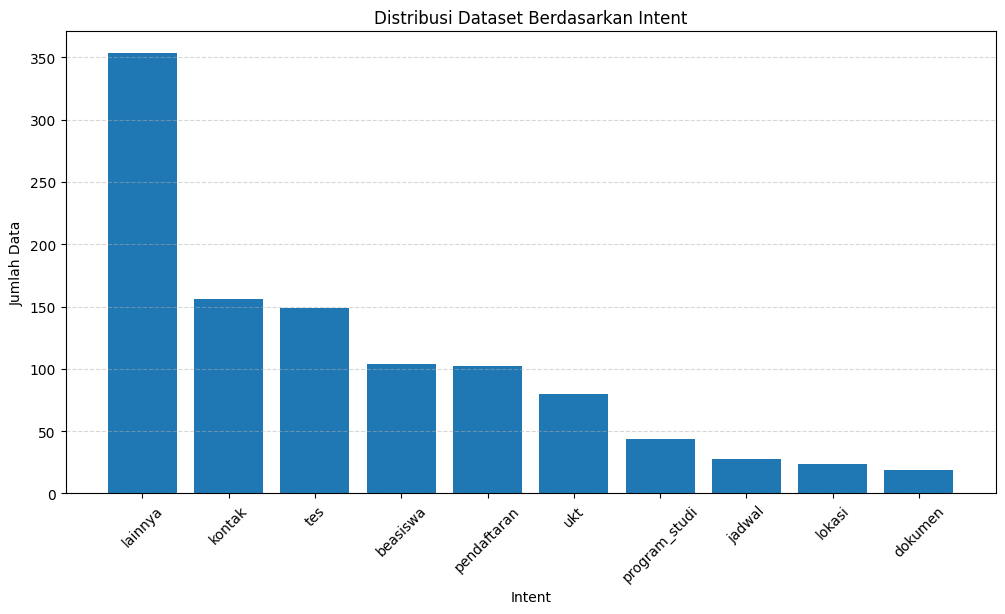

In [12]:
intent_count = df["intent"].value_counts()

plt.figure(figsize=(12,6))

plt.bar(intent_count.index, intent_count.values)

plt.title("Distribusi Dataset Berdasarkan Intent")

plt.xlabel("Intent")

plt.ylabel("Jumlah Data")

plt.xticks(rotation=45)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

Encode Label + Persiapan Training

In [13]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df["label"] = label_encoder.fit_transform(df["intent"])

print("Jumlah Kelas :", len(label_encoder.classes_))
print()

for i, label in enumerate(label_encoder.classes_):
    print(f"{i} --> {label}")

display(df[["clean_query","intent","label"]].head())

Jumlah Kelas : 10

0 --> beasiswa
1 --> dokumen
2 --> jadwal
3 --> kontak
4 --> lainnya
5 --> lokasi
6 --> pendaftaran
7 --> program_studi
8 --> tes
9 --> ukt


,clean_query,intent,label
0,information for prospective agrotechnology stu...,lainnya,4
1,how competitive is communication studies sis b...,lainnya,4
2,so will the golden ticket requirements not be ...,lainnya,4
3,hello sis bro how do i get the golden ticket i...,lainnya,4
4,min may i ask about the mechanical engineering...,lainnya,4


"Mengapa dataset tidak memiliki intent?"


"Dataset PPMB QA hanya menyediakan pasangan pertanyaan dan jawaban. Oleh karena itu, sebelum melatih model Intent Detection, saya melakukan proses pelabelan otomatis (rule-based labeling) menggunakan kata kunci yang relevan dengan domain penerimaan mahasiswa baru, sehingga setiap pertanyaan memiliki label intent yang dapat digunakan pada proses pelatihan IndoBERT."

Train Test Split

In [14]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

print("="*50)
print("Jumlah Data Train :", len(train_df))
print("Jumlah Data Test  :", len(test_df))
print("="*50)

Jumlah Data Train : 847
Jumlah Data Test  : 212


Tokenizer IndoBERT

In [15]:
from transformers import AutoTokenizer

MODEL_NAME = "indobenchmark/indobert-base-p1"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer berhasil dimuat.")

Tokenizer berhasil dimuat.


Tokenisasi Dataset

In [16]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(
    train_df[["clean_query", "label"]]
)

test_dataset = Dataset.from_pandas(
    test_df[["clean_query", "label"]]
)

def tokenize(batch):
    return tokenizer(
        batch["clean_query"],
        truncation=True,
        padding="max_length",
        max_length=64
    )

train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

train_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)

test_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)

print("Dataset siap untuk training.")

Map:   0%|          | 0/847 [00:00<?, ? examples/s]

Map:   0%|          | 0/212 [00:00<?, ? examples/s]

Dataset siap untuk training.


In [17]:
train_texts = train_df["clean_query"].tolist()
test_texts = test_df["clean_query"].tolist()

train_labels = train_df["label"].tolist()
test_labels = test_df["label"].tolist()

print(len(train_texts), len(test_texts))

847 212


In [18]:
from transformers import AutoModelForSequenceClassification

num_labels = len(label_encoder.classes_)

model = AutoModelForSequenceClassification.from_pretrained(
    "indobenchmark/indobert-base-p1",
    num_labels=num_labels
)

print(model.config)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertConfig {
  "_attn_implementation_autoset": true,
  "_name_or_path": "indobenchmark/indobert-base-p1",
  "_num_labels": 5,
  "architectures": [
    "BertModel"
  ],
  "attention_probs_dropout_prob": 0.1,
  "classifier_dropout": null,
  "directionality": "bidi",
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "id2label": {
    "0": "LABEL_0",
    "1": "LABEL_1",
    "2": "LABEL_2",
    "3": "LABEL_3",
    "4": "LABEL_4",
    "5": "LABEL_5",
    "6": "LABEL_6",
    "7": "LABEL_7",
    "8": "LABEL_8",
    "9": "LABEL_9"
  },
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "label2id": {
    "LABEL_0": 0,
    "LABEL_1": 1,
    "LABEL_2": 2,
    "LABEL_3": 3,
    "LABEL_4": 4,
    "LABEL_5": 5,
    "LABEL_6": 6,
    "LABEL_7": 7,
    "LABEL_8": 8,
    "LABEL_9": 9
  },
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "output_past": true,
  "pad_token_id":

In [19]:
#Tokenisasi
from transformers import AutoTokenizer

MODEL_NAME = "indobenchmark/indobert-base-p1"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

In [20]:
#Encode
train_encodings = tokenizer(
    train_texts,
    truncation=True,
    padding=True,
    max_length=64
)

test_encodings = tokenizer(
    test_texts,
    truncation=True,
    padding=True,
    max_length=64
)

In [21]:
#Dataset PyTorch
import torch

class KampusDataset(torch.utils.data.Dataset):

    def __init__(self, encodings, labels):

        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):

        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }

        item["labels"] = torch.tensor(self.labels[idx])

        return item

    def __len__(self):

        return len(self.labels)

In [22]:
# Buat Dataset
train_dataset = KampusDataset(
    train_encodings,
    train_labels
)

test_dataset = KampusDataset(
    test_encodings,
    test_labels
)

In [23]:
#DataLoader
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8
)

In [24]:
#Load IndoBERT
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(

    MODEL_NAME,

    num_labels=len(label_encoder.classes_)

)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [25]:
#Optimizer
from transformers import AdamW

optimizer = AdamW(

    model.parameters(),

    lr=2e-5

)

/usr/local/lib/python3.12/dist-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


In [26]:
#GPU
device = torch.device(

    "cuda"

    if torch.cuda.is_available()

    else

    "cpu"

)

model.to(device)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(50000, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [27]:
#Training Loop
from tqdm import tqdm

epochs = 3

model.train()

for epoch in range(epochs):

    total_loss = 0

    loop = tqdm(train_loader)

    for batch in loop:

        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)

        attention_mask = batch["attention_mask"].to(device)

        labels = batch["labels"].to(device)

        outputs = model(

            input_ids=input_ids,

            attention_mask=attention_mask,

            labels=labels

        )

        loss = outputs.loss

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

        loop.set_description(

            f"Epoch {epoch+1}"

        )

        loop.set_postfix(

            loss=loss.item()

        )

    print(

        "Epoch",

        epoch+1,

        "Loss",

        total_loss/len(train_loader)

    )

Epoch 1: 100%|██████████| 106/106 [00:14<00:00,  7.09it/s, loss=0.444]


Epoch 1 Loss 1.2805249304422792


Epoch 2: 100%|██████████| 106/106 [00:11<00:00,  8.97it/s, loss=0.476]


Epoch 2 Loss 0.3228243483617058


Epoch 3: 100%|██████████| 106/106 [00:11<00:00,  9.00it/s, loss=0.0284]

Epoch 3 Loss 0.13463414086134368


In [28]:
#13.1 Prediksi
model.eval()

predictions = []
true_labels = []

with torch.no_grad():

    for batch in test_loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        preds = torch.argmax(outputs.logits, dim=1)

        predictions.extend(preds.cpu().numpy())
        true_labels.extend(batch["labels"].numpy())

In [29]:
#13.2 Accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(true_labels, predictions)

print("="*50)
print("Accuracy :", accuracy)
print("="*50)

Accuracy : 0.9433962264150944


In [30]:
#13.3 Precision Recall F1
from sklearn.metrics import classification_report

print(
    classification_report(
        true_labels,
        predictions,
        target_names=label_encoder.classes_
    )
)

               precision    recall  f1-score   support

     beasiswa       1.00      1.00      1.00        21
      dokumen       0.60      0.75      0.67         4
       jadwal       1.00      1.00      1.00         5
       kontak       1.00      0.90      0.95        31
      lainnya       0.88      0.96      0.92        71
       lokasi       0.75      0.60      0.67         5
  pendaftaran       1.00      1.00      1.00        20
program_studi       1.00      1.00      1.00         9
          tes       1.00      0.90      0.95        30
          ukt       1.00      1.00      1.00        16

     accuracy                           0.94       212
    macro avg       0.92      0.91      0.91       212
 weighted avg       0.95      0.94      0.94       212



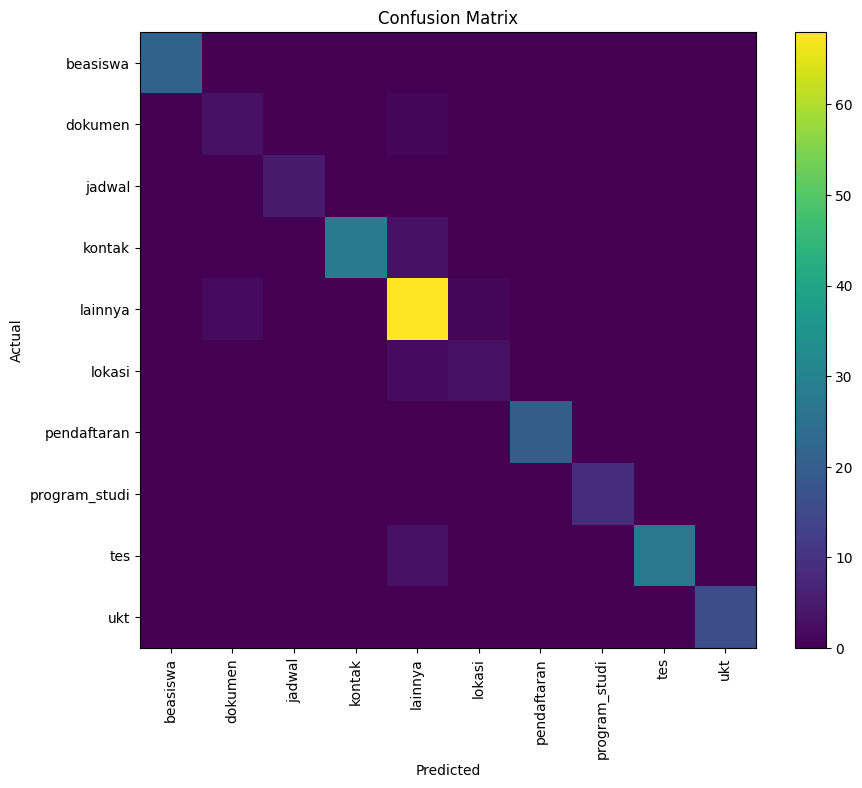

In [31]:
#13.4 Confusion Matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(true_labels, predictions)

plt.figure(figsize=(10,8))

plt.imshow(cm)

plt.colorbar()

plt.xticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_,
    rotation=90
)

plt.yticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [32]:
#(Simpan Model)
import os

os.makedirs("model_chatbot", exist_ok=True)

model.save_pretrained("model_chatbot")

tokenizer.save_pretrained("model_chatbot")

('model_chatbot/tokenizer_config.json',
 'model_chatbot/special_tokens_map.json',
 'model_chatbot/vocab.txt',
 'model_chatbot/added_tokens.json',
 'model_chatbot/tokenizer.json')

In [33]:
#(Simpan Label Encoder)
import joblib

joblib.dump(label_encoder, "label_encoder.pkl")

['label_encoder.pkl']

In [34]:
# (Uji Chatbot)
# responses = {

#     "ukt":"Informasi UKT dapat dilihat pada website resmi PMB.",

#     "beasiswa":"Informasi beasiswa tersedia pada menu Beasiswa.",

#     "pendaftaran":"Pendaftaran dilakukan melalui website PMB.",

#     "tes":"Silakan melihat jadwal tes pada akun PMB.",

#     "jadwal":"Silakan cek jadwal terbaru pada website PMB.",

#     "program_studi":"Informasi program studi tersedia pada website resmi.",

#     "lokasi":"Lokasi kampus dapat dilihat pada Google Maps.",

#     "dokumen":"Dokumen persyaratan tersedia pada menu Persyaratan.",

#     "kontak":"Silakan hubungi admin PMB.",

#     "lainnya":"Maaf, saya belum memahami pertanyaan Anda."
# }

In [35]:
def predict_intent(text):

    model.eval()

    encoding = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=64
    )

    encoding = {k:v.to(device) for k,v in encoding.items()}

    with torch.no_grad():

        output = model(**encoding)

        pred = torch.argmax(output.logits, dim=1).item()

    return label_encoder.inverse_transform([pred])[0]

In [36]:
def cari_jawaban(user_text, intent):

    kandidat = df[df["intent"] == intent]

    if len(kandidat) == 0:
        return "Maaf, jawaban belum tersedia."

    skor_terbaik = 0
    jawaban_terbaik = ""

    for _, row in kandidat.iterrows():

        skor = SequenceMatcher(
            None,
            user_text.lower(),
            row["clean_query"]
        ).ratio()

        if skor > skor_terbaik:

            skor_terbaik = skor
            jawaban_terbaik = row["answer"]

    return jawaban_terbaik

In [37]:
def extract_entities(text):

    text = text.lower()

    entities = []

    # Fakultas
    fakultas = [
        "teknik",
        "kedokteran",
        "ekonomi",
        "hukum",
        "pertanian",
        "informatika",
        "fisip",
        "fkip"
    ]

    # Jalur Masuk
    jalur = [
        "snbp",
        "snbt",
        "mandiri",
        "kip",
        "beasiswa"
    ]

    # Dokumen
    dokumen = [
        "ktp",
        "kk",
        "ijazah",
        "rapor",
        "pas foto"
    ]

    for item in fakultas:
        if item in text:
            entities.append(("FAKULTAS", item))

    for item in jalur:
        if item in text:
            entities.append(("JALUR_MASUK", item))

    for item in dokumen:
        if item in text:
            entities.append(("DOKUMEN", item))

    return entities

### Conversation History Feature

In [38]:
conversation_history_df = pd.DataFrame(columns=['user_input', 'predicted_intent', 'extracted_entity', 'chatbot_response'])
print('Conversation history DataFrame initialized.')

Conversation history DataFrame initialized.


In [39]:
while True:

    text = input("Anda : ")

    if text.lower() in ["keluar","exit","selesai"]:
        print("Chatbot : Terima kasih.")
        break

    intent = predict_intent(text)

    entity = extract_entities(text)

    jawaban = cari_jawaban(text, intent)

    print("="*60)
    print("Intent :", intent)
    print("Entity :", entity)
    print()
    print("Jawaban :")
    print(jawaban)
    print("="*60)

Anda : uk berapa
Intent : ukt
Entity : []

Jawaban :
Berdasarkan sumber yang diberikan, berikut adalah informasi mengenai biaya pendaftaran:

*   **Seleksi Nasional Berdasarkan Prestasi (SNBP)**: Biaya pendaftaran ditanggung oleh Pemerintah.
*   **Seleksi Nasional Berdasarkan Tes (SNBT)**: Peserta wajib membayar biaya UTBK sebesar **Rp200.000,00 (dua ratus ribu rupiah)**. Biaya ini dapat dibayarkan melalui mitra bank seperti Mandiri, BNI, BTN, BRI, dan BSI.
*   **Seleksi Mandiri (SM-Rapor, SM-UTBK, SM-Prestasi, SM-CBT)**: Biaya formulir Seleksi Mandiri adalah **Rp350.000,00 (tiga ratus lima puluh ribu rupiah)** untuk satu kali jenis tahap seleksi. Setiap peserta dapat memilih dua program studi dalam satu jenis seleksi mandiri.

Perlu diperhatikan bahwa untuk pelamar beasiswa KIP Kuliah, terdapat pembebasan biaya pendaftaran seleksi masuk perguruan tinggi di bawah naungan Kemdiktisaintek melalui jalur UTBK-SNBT.
Anda : selesai
Chatbot : Terima kasih.


In [40]:
while True:
    # Display last 5 conversation history entries
    if not conversation_history_df.empty:
        print("\n--- Last 5 Conversations ---")
        print(conversation_history_df.tail(5))
        print("----------------------------\n")

    text = input("Anda : ")

    if text.lower() in ["keluar","exit","selesai"]:
        print("Chatbot : Terima kasih.")
        break

    intent = predict_intent(text)

    entity = extract_entities(text)

    jawaban = cari_jawaban(text, intent)

    print("="*60)
    print("Intent :", intent)
    print("Entity :", entity)
    print()
    print("Jawaban :")
    print(jawaban)
    print("="*60)

    # Add current interaction to history
    new_entry = pd.DataFrame([
        {
            'user_input': text,
            'predicted_intent': intent,
            'extracted_entity': str(entity), # Convert list to string for DataFrame
            'chatbot_response': jawaban
        }
    ])
    conversation_history_df = pd.concat([conversation_history_df, new_entry], ignore_index=True)

Anda : ukt berapa
Intent : ukt
Entity : []

Jawaban :
Berdasarkan sumber yang diberikan, berikut adalah informasi mengenai biaya pendaftaran:

*   **Seleksi Nasional Berdasarkan Prestasi (SNBP)**: Biaya pendaftaran ditanggung oleh Pemerintah.
*   **Seleksi Nasional Berdasarkan Tes (SNBT)**: Peserta wajib membayar biaya UTBK sebesar **Rp200.000,00 (dua ratus ribu rupiah)**. Biaya ini dapat dibayarkan melalui mitra bank seperti Mandiri, BNI, BTN, BRI, dan BSI.
*   **Seleksi Mandiri (SM-Rapor, SM-UTBK, SM-Prestasi, SM-CBT)**: Biaya formulir Seleksi Mandiri adalah **Rp350.000,00 (tiga ratus lima puluh ribu rupiah)** untuk satu kali jenis tahap seleksi. Setiap peserta dapat memilih dua program studi dalam satu jenis seleksi mandiri.

Perlu diperhatikan bahwa untuk pelamar beasiswa KIP Kuliah, terdapat pembebasan biaya pendaftaran seleksi masuk perguruan tinggi di bawah naungan Kemdiktisaintek melalui jalur UTBK-SNBT.

--- Last 5 Conversations ---
   user_input predicted_intent extracted_ent

In [41]:
!pip uninstall -y gradio
!pip install gradio==5.34.2

Found existing installation: gradio 5.34.2
Uninstalling gradio-5.34.2:
  Successfully uninstalled gradio-5.34.2
  Using cached gradio-5.34.2-py3-none-any.whl.metadata (16 kB)
Using cached gradio-5.34.2-py3-none-any.whl (54.3 MB)


In [42]:
import gradio as gr
import pandas as pd

# ============================
# Fungsi Chatbot
# ============================

def chatbot(user_input):

    intent = predict_intent(user_input)

    entity = extract_entities(user_input)

    jawaban = cari_jawaban(user_input, intent)

    # simpan history
    global conversation_history_df

    new_data = pd.DataFrame([{
        "Pertanyaan": user_input,
        "Intent": intent,
        "Entity": str(entity),
        "Jawaban": jawaban
    }])

    conversation_history_df = pd.concat(
        [conversation_history_df, new_data],
        ignore_index=True
    )

    history = conversation_history_df.tail(5)

    return (
        intent,
        str(entity),
        jawaban,
        history
    )

In [ ]:
import gradio as gr
import pandas as pd

# ==========================================
# History
# ==========================================

conversation_history_df = pd.DataFrame(
    columns=["Pertanyaan","Intent","Entity","Jawaban"]
)

# ==========================================
# Fungsi chatbot
# ==========================================

def chatbot(user_input):

    global conversation_history_df

    if user_input.strip() == "":
        return "", "", "Silakan masukkan pertanyaan.", conversation_history_df

    intent = predict_intent(user_input)

    entity = extract_entities(user_input)

    jawaban = cari_jawaban(user_input, intent)

    conversation_history_df.loc[len(conversation_history_df)] = [
        user_input,
        intent,
        str(entity),
        jawaban
    ]

    return (
        intent,
        str(entity),
        jawaban,
        conversation_history_df.tail(10)
    )


# ==========================================
# Interface
# ==========================================

with gr.Blocks() as demo:

    gr.Markdown("# 🎓 Chatbot FAQ Kampus")
    gr.Markdown("## UAS Natural Language Processing")

    with gr.Row():

        with gr.Column(scale=2):

            pertanyaan = gr.Textbox(
                label="Masukkan Pertanyaan",
                placeholder="Contoh: Berapa UKT Teknik Informatika?",
                lines=2
            )

            tombol = gr.Button(
                value="🚀 Kirim",
                variant="primary"
            )

        with gr.Column(scale=2):

            intent = gr.Textbox(
                label="Intent",
                interactive=False
            )

            entity = gr.Textbox(
                label="Entity",
                interactive=False
            )

            jawaban = gr.Textbox(
                label="Jawaban",
                lines=8,
                interactive=False
            )

    gr.Markdown("## Riwayat Percakapan")

    history = gr.Dataframe(
        headers=[
            "Pertanyaan",
            "Intent",
            "Entity",
            "Jawaban"
        ],
        interactive=False
    )

    tombol.click(
        fn=chatbot,
        inputs=[pertanyaan],
        outputs=[
            intent,
            entity,
            jawaban,
            history
        ]
    )

demo.launch(debug=True)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().

Could not create share link. Please check your internet connection or our status page: https://status.gradio.app.


2026/06/30 22:59:38 [W] [service.go:132] login to server failed: session shutdown


<IPython.core.display.Javascript object>